In [1]:
import glob
import gc
import time
from pathlib import Path

import numpy as np
import pandas as pd
import gseapy

from matplotlib import pyplot as plt
import seaborn as sns

%matplotlib inline

In [2]:
## PATH & IMPORT ##

# define paths #
MASHR_PATH = Path("/mnt/sdb/scz_meta_analysis_processed/mash_results/")
MASHR_PATH = Path(MASHR_PATH)

# import mashR output files #
pm = pd.read_csv(MASHR_PATH / "mash_posterior_mean.csv", index_col=0)
lfsr = pd.read_csv(MASHR_PATH / "mash_lfsr.csv", index_col=0)
logFC_orig = pd.read_csv(MASHR_PATH / "mash_logFC_original.csv", index_col=0)
post_sd = pd.read_csv(MASHR_PATH / "mash_posterior_sd.csv", index_col=0)
neg_prob = pd.read_csv(MASHR_PATH / "mash_negative_prob.csv", index_col=0)

# import significance and missingness QC #
mash_sig_any_gene = pd.read_csv(MASHR_PATH / "mash_sig_any_gene.csv", index_col=0)
mash_sig_per_celltype = pd.read_csv(MASHR_PATH / "mash_sig_per_celltype.csv", index_col=0)
gene_missingness = pd.read_csv(MASHR_PATH / "gene_missingness.csv", index_col=0)
celltype_missingness = pd.read_csv(MASHR_PATH / "celltype_missingness.csv", index_col=0)

In [3]:
## prior Composite Testing CSVs ##

glob.glob("/mnt/sdb/scz_meta_analysis_processed/mash_results/composite*all*") 

['/mnt/sdb/scz_meta_analysis_processed/mash_results/composite_Dorsal_Forebrain_Neuron_FOXG1+EMX1+NEUROG1+_all.csv',
 '/mnt/sdb/scz_meta_analysis_processed/mash_results/composite_Radial_Glia_SOX2+VIM+FABP7+_all.csv',
 '/mnt/sdb/scz_meta_analysis_processed/mash_results/composite_Radial_Glia_SOX2+PAX6+FABP7+_all.csv',
 '/mnt/sdb/scz_meta_analysis_processed/mash_results/composite_Mesenchymal-like_cells_VIM+VCAN+SPARC+_all.csv',
 '/mnt/sdb/scz_meta_analysis_processed/mash_results/composite_GABAergic_GAD1+GAD2+CALB2+_all.csv',
 '/mnt/sdb/scz_meta_analysis_processed/mash_results/composite_Proliferative_Radial_Glia_SOX2+HES6+TOP2A+_all.csv',
 '/mnt/sdb/scz_meta_analysis_processed/mash_results/composite_Hindbrain_Neurons_NR2F2+PBX3+LHX1+_all.csv',
 '/mnt/sdb/scz_meta_analysis_processed/mash_results/composite_IPC_EOMES+NEUROG2+PAX6+_all.csv',
 '/mnt/sdb/scz_meta_analysis_processed/mash_results/composite_Mixed_Neurons_FGF12+GRIN2B+CAMK2B+_all.csv',
 '/mnt/sdb/scz_meta_analysis_processed/mash_resu

In [4]:
dfn_composite = pd.read_csv('/mnt/sdb/scz_meta_analysis_processed/mash_results/composite_Dorsal_Forebrain_Neuron_FOXG1+EMX1+NEUROG1+_all.csv')
rg_vim_composite = pd.read_csv('/mnt/sdb/scz_meta_analysis_processed/mash_results/composite_Radial_Glia_SOX2+VIM+FABP7+_all.csv')
rg_pax_composite = pd.read_csv('/mnt/sdb/scz_meta_analysis_processed/mash_results/composite_Radial_Glia_SOX2+PAX6+FABP7+_all.csv')
mc_composite = pd.read_csv('/mnt/sdb/scz_meta_analysis_processed/mash_results/composite_Mesenchymal-like_cells_VIM+VCAN+SPARC+_all.csv')
gaba_composite = pd.read_csv('/mnt/sdb/scz_meta_analysis_processed/mash_results/composite_GABAergic_GAD1+GAD2+CALB2+_all.csv')
prg_composite = pd.read_csv('/mnt/sdb/scz_meta_analysis_processed/mash_results/composite_Proliferative_Radial_Glia_SOX2+HES6+TOP2A+_all.csv')
ipc_composite = pd.read_csv('/mnt/sdb/scz_meta_analysis_processed/mash_results/composite_IPC_EOMES+NEUROG2+PAX6+_all.csv')
mn_composite = pd.read_csv('/mnt/sdb/scz_meta_analysis_processed/mash_results/composite_Mixed_Neurons_FGF12+GRIN2B+CAMK2B+_all.csv')
astro_composite = pd.read_csv('/mnt/sdb/scz_meta_analysis_processed/mash_results/composite_Astrocyte_GFAP+AQP4+HOPX+_all.csv')

In [5]:
combined = pd.DataFrame({
    "gene": dfn_composite["gene"],
    "score_dfn": dfn_composite["score"],
    "score_rg_vim": rg_vim_composite["score"],
    "score_rg_pax": rg_pax_composite["score"],
    "score_mc": mc_composite["score"],
    "score_gaba": gaba_composite["score"],
    "score_prg": prg_composite["score"],
    "score_ipc": ipc_composite["score"],
    "score_mn": mn_composite["score"],
    "score_astro": astro_composite["score"],
})

combined = combined.set_index("gene")

In [6]:
print((dfn_composite['score'] > 0.50).sum())
print((rg_vim_composite['score'] > 0.50).sum())
print((rg_pax_composite['score'] > 0.50).sum())
print((mc_composite['score'] > 0.5).sum())
print((gaba_composite['score'] > 0.5).sum())
print((prg_composite['score'] > 0.5).sum())
print((ipc_composite['score'] > 0.5).sum())
print((mn_composite['score'] > 0.5).sum())
print((astro_composite['score'] > 0.5).sum())

8
14
19
16
19
59
18
52
25


In [7]:
## extrat the only genes where anythign has any possibility of being shared

combined[(combined > 0.5).sum(axis=1) > 0]

,score_dfn,score_rg_vim,score_rg_pax,score_mc,score_gaba,score_prg,score_ipc,score_mn,score_astro
gene,,,,,,,,,
ACAA2,0.159720,0.347963,0.134031,0.145468,0.205788,0.137755,0.273404,0.538779,0.376340
ACAT2,0.407466,0.099882,0.223969,0.337446,0.183733,0.625990,0.332333,0.506287,0.476044
ACOX1,0.163412,0.151322,0.192275,0.162627,0.200879,0.517645,0.234920,0.197504,0.303038
ADGRL3,0.669733,0.382546,0.526772,0.666643,0.706449,0.662350,0.632017,0.561243,0.640070
ADI1,0.094747,0.364802,0.178974,0.153200,0.187117,0.169420,0.508391,0.261768,0.242537
...,...,...,...,...,...,...,...,...,...
UFD1,0.160970,0.169089,0.135381,0.198250,0.423212,0.484792,0.270249,0.500716,0.241842
VCAN,0.115270,0.263001,0.223361,0.164895,0.588626,0.248724,0.210057,0.110193,0.258550
ZNF286A,0.150791,0.168858,0.098263,0.062768,0.075455,0.455941,0.126337,0.602617,0.126354


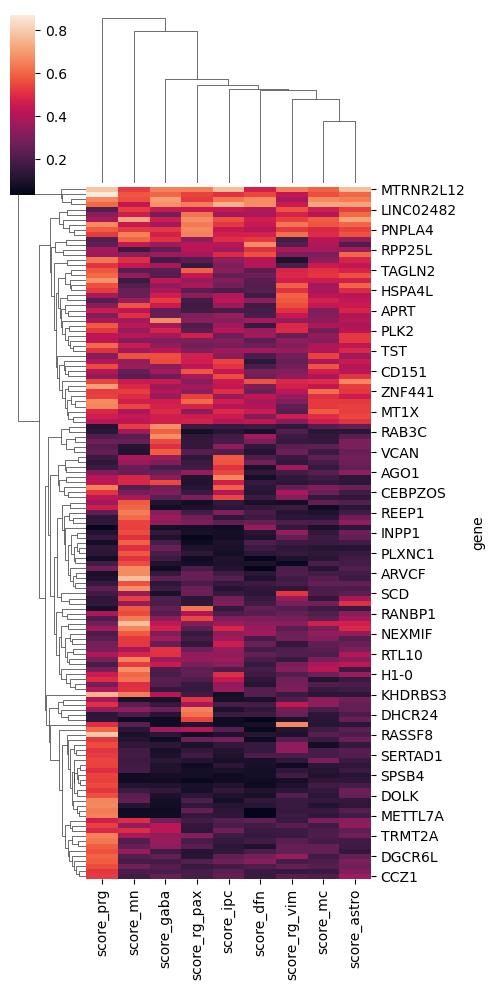

In [8]:
sns.clustermap(combined[(combined > 0.5).sum(axis=1) > 0], figsize=(5, 10))

In [9]:
combined

,score_dfn,score_rg_vim,score_rg_pax,score_mc,score_gaba,score_prg,score_ipc,score_mn,score_astro
gene,,,,,,,,,
A1BG,2.563549e-10,1.583068e-09,3.105746e-10,9.901571e-08,7.875674e-09,7.812369e-09,1.166373e-07,5.288874e-09,2.327286e-06
A1BG-AS1,4.209955e-03,1.332478e-02,2.603408e-03,1.015776e-02,8.140773e-03,5.171922e-03,6.409552e-03,8.756570e-03,2.291266e-02
AAAS,9.814688e-12,7.130410e-10,1.022056e-11,3.280456e-09,3.903364e-10,1.135626e-10,3.296728e-09,3.843062e-10,8.599443e-07
AACS,9.740451e-06,2.175548e-05,2.589885e-05,9.951007e-05,5.262408e-05,9.587546e-05,8.967871e-05,6.664232e-05,6.651898e-04
AADAT,3.622944e-12,3.163233e-12,4.390483e-10,3.707034e-09,5.365799e-10,1.493085e-11,3.521164e-10,1.235964e-09,8.165186e-08
...,...,...,...,...,...,...,...,...,...
ZXDC,1.060773e-10,1.208743e-09,1.402100e-10,4.640650e-08,2.300881e-09,1.509626e-09,9.404660e-09,1.828314e-09,2.011660e-06
ZYG11B,7.277924e-14,1.007101e-10,3.262070e-14,7.454407e-11,1.256154e-12,2.072838e-12,1.190597e-11,1.530186e-12,2.566010e-08
ZYX,2.126292e-03,1.423693e-03,2.405658e-03,6.539220e-03,5.166601e-03,9.217432e-03,3.646626e-03,6.876502e-03,1.799993e-02


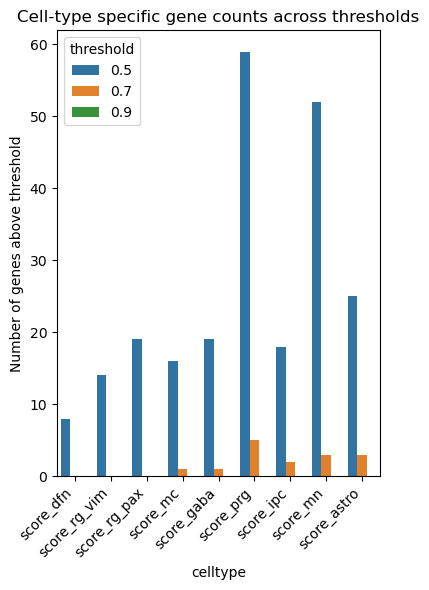

In [10]:
thresholds = [0.5, 0.7, 0.9]

data = []

for t in thresholds:
    counts = (combined > t).sum(axis=0)  # per cell type
    for celltype, value in counts.items():
        data.append({
            "celltype": celltype,
            "threshold": str(t),
            "count": value
        })

df = pd.DataFrame(data)


plt.figure(figsize=(4,6))

sns.barplot(
    data=df,
    x="celltype",
    y="count",
    hue="threshold"
)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of genes above threshold")
plt.title("Cell-type specific gene counts across thresholds")
plt.tight_layout()

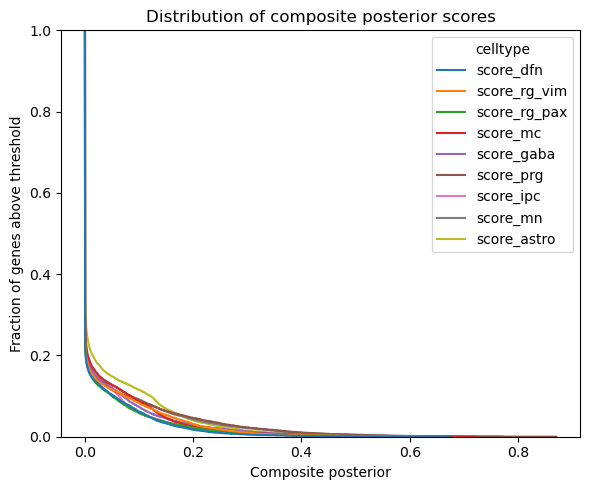

In [11]:
plot_df = (
    combined
    .reset_index(drop=True)
    .melt(var_name="celltype", value_name="posterior")
)

plt.figure(figsize=(6,5))

sns.ecdfplot(
    data=plot_df,
    x="posterior",
    hue="celltype",
    complementary=True  # plots P(score > x)
)

plt.xlabel("Composite posterior")
plt.ylabel("Fraction of genes above threshold")
plt.title("Distribution of composite posterior scores")
plt.tight_layout()

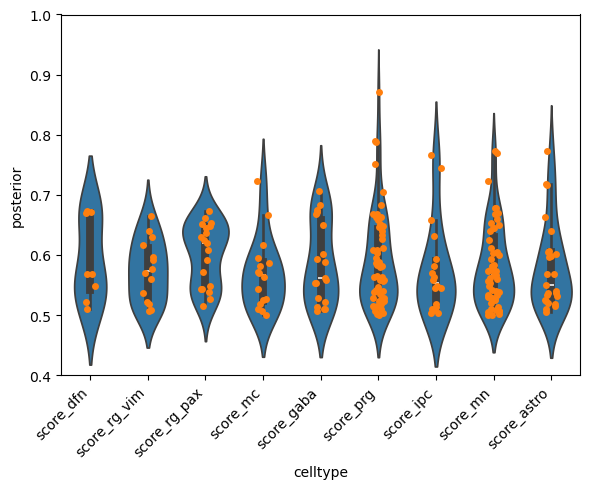

In [12]:
plot_df = (
    combined
    .reset_index(drop=True)
    .melt(var_name="celltype", value_name="posterior")
)

plot_df = plot_df[plot_df['posterior'] > 0.5]

plt.figure(figsize=(6,5))

sns.violinplot(
    data=plot_df,
    x="celltype",
    y="posterior",
    #inner="quartile",
  #  cut=0
)

sns.stripplot(
    data=plot_df,
    x="celltype",
    y="posterior",
    #inner="quartile",
  #  cut=0
)

plt.ylim(0.4, 1)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

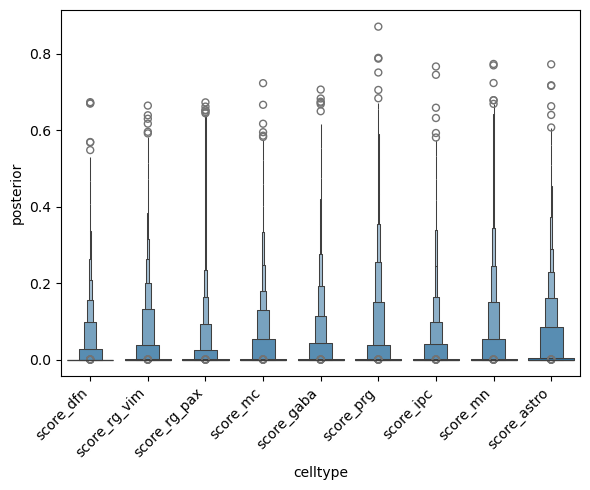

In [13]:
plot_df = (
    combined
    .reset_index(drop=True)
    .melt(var_name="celltype", value_name="posterior")
)

plt.figure(figsize=(6,5))

sns.boxenplot(
    data=plot_df,
    x="celltype",
    y="posterior"
)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()

<Axes: xlabel='gene'>

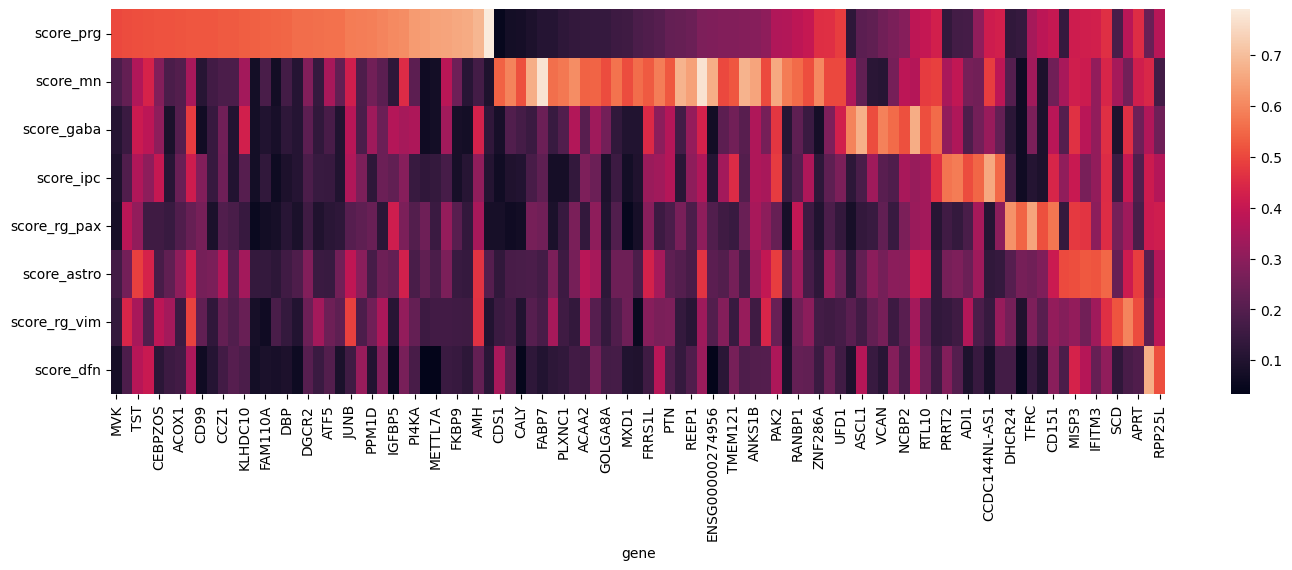

In [14]:
specific = combined[(combined > 0.5).sum(axis=1) == 1]

winner = (specific > 0.5).idxmax(axis=1)

# Count how many genes belong to each cell type
block_sizes = winner.value_counts()

# Order cell types from largest block to smallest
col_order = block_sizes.index.tolist()

# Reorder columns
specific = specific[col_order]

# Make winner a categorical with the desired ordering
winner = pd.Categorical(
    winner,
    categories=col_order,
    ordered=True
)

# Sort rows by block, then by score within each block
specific = (
    specific.assign(winner=winner)
            .sort_values(["winner"] + col_order, ascending=False)
            .drop(columns="winner")
)

specific = specific.iloc[::-1]

plt.figure(figsize=(17,5))
sns.heatmap(specific.T, yticklabels=True)

In [15]:
celltype_gene_mash_df = pd.DataFrame([[i.removeprefix('score_') for i in winner], specific.index], index=['celltype', 'gene']).T
mash_gseapy_dict = celltype_gene_mash_df.groupby('celltype').agg(list)['gene'].to_dict()

In [16]:
enrichr_results = []

for celltype in mash_gseapy_dict.keys():
    res = gseapy.enrichr(
        gene_list=mash_gseapy_dict[celltype],
        gene_sets='GO_Biological_Process_2026',
        organism='hs'
    ).results.copy()

    # add label
    res['celltype'] = celltype

    enrichr_results.append(res)

    time.sleep(1.5)

# combine everything
enrich_df = pd.concat(enrichr_results, ignore_index=True)

enrich_df['Term_cleaned'] = enrich_df['Term'].str.replace(r'\s*\(GO:[^)]+\)$', '', regex=True).str.strip()

enrich_df['neglogP'] = -np.log10(enrich_df['Adjusted P-value'])

/tmp/ipykernel_329257/1281939452.py:18: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  enrich_df = pd.concat(enrichr_results, ignore_index=True)


In [17]:
enrich_df[enrich_df['Adjusted P-value'] < 0.05].groupby('celltype').head(10)

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes,celltype,Term_cleaned,neglogP
0,GO_Biological_Process_2026,Golgi Organization (GO:0007030),2/128,0.000401,0.004013,0,0,105.126984,822.174362,GOLGA8B;GOLGA8A,astro,Golgi Organization,2.396519
1,GO_Biological_Process_2026,Endomembrane System Organization (GO:0010256),2/201,0.000985,0.004926,0,0,66.318258,459.100965,GOLGA8B;GOLGA8A,astro,Endomembrane System Organization,2.307518
2,GO_Biological_Process_2026,Organelle Organization (GO:0006996),2/442,0.004662,0.011475,0,0,29.628788,159.054696,GOLGA8B;GOLGA8A,astro,Organelle Organization,1.940263
3,GO_Biological_Process_2026,Protein Localization to Microtubule Organizing...,1/20,0.004990,0.011475,0,0,262.842105,1393.123889,C2CD3,astro,Protein Localization to Microtubule Organizing...,1.940263
4,GO_Biological_Process_2026,Protein Localization to Centrosome (GO:0071539),1/23,0.005737,0.011475,0,0,226.965909,1171.318505,C2CD3,astro,Protein Localization to Centrosome,1.940263
5,GO_Biological_Process_2026,Non-motile Cilium Assembly (GO:1905515),1/33,0.008224,0.013706,0,0,155.960938,748.730022,C2CD3,astro,Non-motile Cilium Assembly,1.863092
118,GO_Biological_Process_2026,Negative Regulation of Glycoprotein Metabolic ...,1/6,0.001799,0.027994,0,0,799.560000,5053.709148,MEST,ipc,Negative Regulation of Glycoprotein Metabolic ...,1.552942
119,GO_Biological_Process_2026,Regulation of Protein Polyubiquitination (GO:1...,1/8,0.002398,0.027994,0,0,571.057143,3445.289983,SPSB4,ipc,Regulation of Protein Polyubiquitination,1.552942
120,GO_Biological_Process_2026,Negative Regulation of Mitochondrial Fusion (G...,1/8,0.002398,0.027994,0,0,571.057143,3445.289983,TFRC,ipc,Negative Regulation of Mitochondrial Fusion,1.552942
121,GO_Biological_Process_2026,Sulfur Amino Acid Catabolic Process (GO:0000098),1/11,0.003296,0.027994,0,0,399.680000,2284.210592,TST,ipc,Sulfur Amino Acid Catabolic Process,1.552942


/tmp/ipykernel_329257/80705567.py:19: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


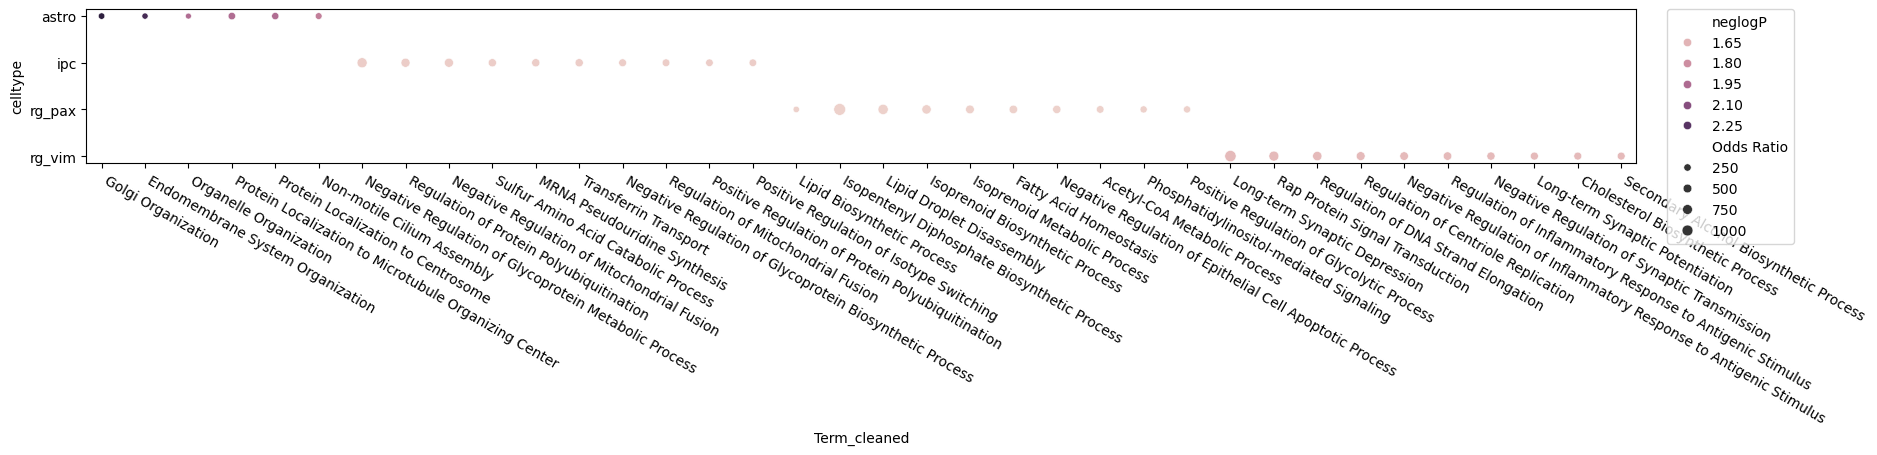

In [18]:
plt.figure(figsize=(20, 2))

ax = sns.scatterplot(
    data=enrich_df[enrich_df['Adjusted P-value'] < 0.05].groupby('celltype').head(10),
    y='celltype',
    x='Term_cleaned',
    size='Odds Ratio',
    hue='neglogP',
)

plt.xticks(rotation=-30, ha='left')

ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    borderaxespad=0
)
ax.margins(x=0.01)  # remove x padding
plt.tight_layout()
plt.show()

In [19]:
## Minus 15q13 ##

gaba_comp_minus_15q13 = pd.read_csv('/mnt/sdb/scz_meta_analysis_processed/mash_results/minus_15q13_composite_GABAergic_GAD1+GAD2+CALB2+_all.csv')
rg_vim_comp_minus_15q13 = pd.read_csv('/mnt/sdb/scz_meta_analysis_processed/mash_results/minus_15q13_composite_Radial_Glia_SOX2+VIM+FABP7+_all.csv')
rg_pax_comp_minus_15q13 = pd.read_csv('/mnt/sdb/scz_meta_analysis_processed/mash_results/minus_15q13_composite_Radial_Glia_SOX2+PAX6+FABP7+_all.csv')
mn_comp_minus_15q13 = pd.read_csv('/mnt/sdb/scz_meta_analysis_processed/mash_results/minus_15q13_composite_Mixed_Neurons_FGF12+GRIN2B+CAMK2B+_all.csv')
ipc_comp_minus_15q13 = pd.read_csv('/mnt/sdb/scz_meta_analysis_processed/mash_results/minus_15q13_composite_IPC_EOMES+NEUROG2+PAX6+_all.csv')
dfn_comp_minus_15q13 = pd.read_csv('/mnt/sdb/scz_meta_analysis_processed/mash_results/minus_15q13_composite_Dorsal_Forebrain_Neuron_FOXG1+EMX1+NEUROG1+_all.csv')
mc_comp_minus_15q13 = pd.read_csv('/mnt/sdb/scz_meta_analysis_processed/mash_results/minus_15q13_composite_Mesenchymal-like_cells_VIM+VCAN+SPARC+_all.csv')
prg_comp_minus_15q13 = pd.read_csv('/mnt/sdb/scz_meta_analysis_processed/mash_results/minus_15q13_composite_Proliferative_Radial_Glia_SOX2+HES6+TOP2A+_all.csv')
hindbrain_comp_minus_15q13 = pd.read_csv('/mnt/sdb/scz_meta_analysis_processed/mash_results/minus_15q13_composite_Hindbrain_Neurons_NR2F2+PBX3+LHX1+_all.csv')
astro_comp_minus_15q13 = pd.read_csv('/mnt/sdb/scz_meta_analysis_processed/mash_results/minus_15q13_composite_Astrocyte_GFAP+AQP4+HOPX+_all.csv')

In [20]:
combined_minus_15q13 = pd.DataFrame({
    "gene": dfn_comp_minus_15q13["gene"],
    "score_dfn": dfn_comp_minus_15q13["score"],
    "score_rg_vim": rg_vim_comp_minus_15q13["score"],
    "score_rg_pax": rg_pax_comp_minus_15q13["score"],
    "score_mc": mc_comp_minus_15q13["score"],
    "score_gaba": gaba_comp_minus_15q13["score"],
    "score_prg": prg_comp_minus_15q13["score"],
    "score_ipc": ipc_comp_minus_15q13["score"],
    "score_mn": mn_comp_minus_15q13["score"],
    "score_hindbrain": hindbrain_comp_minus_15q13["score"],
    "score_astro": astro_comp_minus_15q13["score"],
})

combined_minus_15q13 = combined_minus_15q13.set_index("gene")

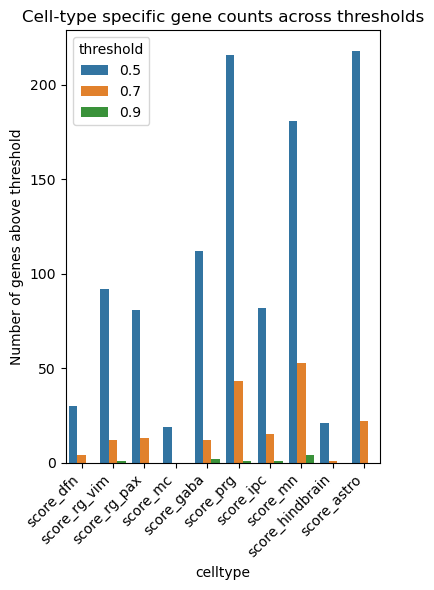

In [21]:
thresholds = [0.5, 0.7, 0.9]

data = []

for t in thresholds:
    counts = (combined_minus_15q13 > t).sum(axis=0)  # per cell type
    for celltype, value in counts.items():
        data.append({
            "celltype": celltype,
            "threshold": str(t),
            "count": value
        })

df = pd.DataFrame(data)


plt.figure(figsize=(4,6))

sns.barplot(
    data=df,
    x="celltype",
    y="count",
    hue="threshold"
)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of genes above threshold")
plt.title("Cell-type specific gene counts across thresholds")
plt.tight_layout()

<Axes: xlabel='gene'>

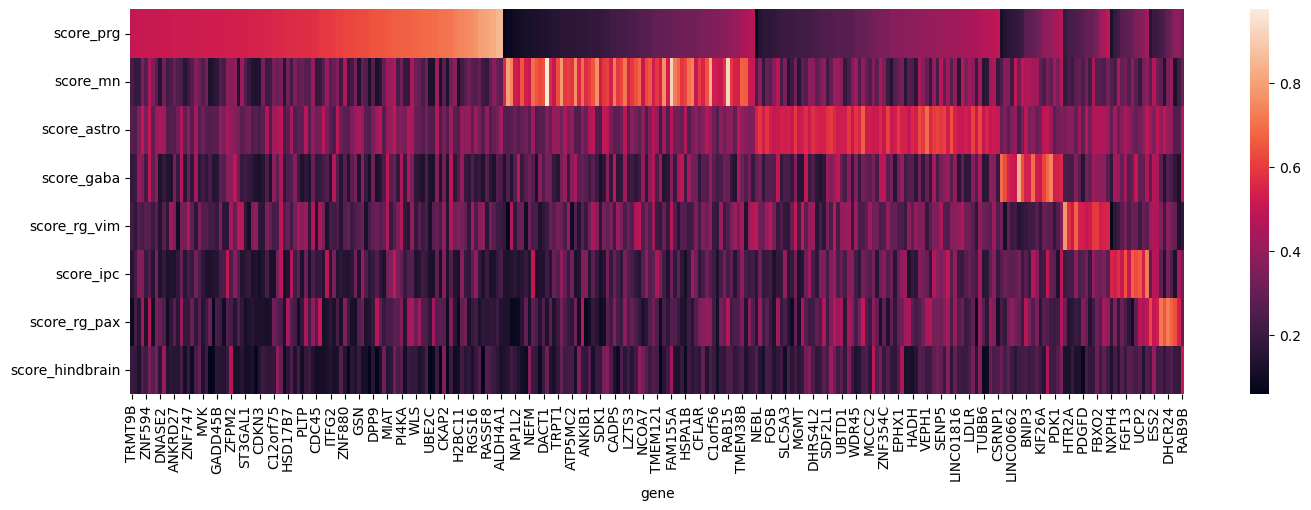

In [22]:
specific = combined_minus_15q13[(combined_minus_15q13 > 0.5).sum(axis=1) == 1]

winner = (specific > 0.5).idxmax(axis=1)

# Count how many genes belong to each cell type
block_sizes = winner.value_counts()

# Order cell types from largest block to smallest
col_order = block_sizes.index.tolist()

# Reorder columns
specific = specific[col_order]

# Make winner a categorical with the desired ordering
winner = pd.Categorical(
    winner,
    categories=col_order,
    ordered=True
)

# Sort rows by block, then by score within each block
specific = (
    specific.assign(winner=winner)
            .sort_values(["winner"] + col_order, ascending=False)
            .drop(columns="winner")
)

specific = specific.iloc[::-1]

plt.figure(figsize=(17,5))
sns.heatmap(specific.T, yticklabels=True)

In [23]:
## Read in minus 3q29 and 15q13 ##

ipc_comp_minus_3q29_15q13 = pd.read_csv('/mnt/sdb/scz_meta_analysis_processed/mash_results/minus_3q29_15q13_composite_IPC_EOMES+NEUROG2+PAX6+_all.csv')
hindbrain_comp_minus_3q29_15q13 = pd.read_csv('/mnt/sdb/scz_meta_analysis_processed/mash_results/minus_3q29_15q13_composite_Hindbrain_Neurons_NR2F2+PBX3+LHX1+_all.csv')
mn_comp_minus_3q29_15q13 = pd.read_csv('/mnt/sdb/scz_meta_analysis_processed/mash_results/minus_3q29_15q13_composite_Mixed_Neurons_FGF12+GRIN2B+CAMK2B+_all.csv')
dfn_comp_minus_3q29_15q13 = pd.read_csv('/mnt/sdb/scz_meta_analysis_processed/mash_results/minus_3q29_15q13_composite_Dorsal_Forebrain_Neuron_FOXG1+EMX1+NEUROG1+_all.csv')
mc_comp_minus_3q29_15q13 = pd.read_csv('/mnt/sdb/scz_meta_analysis_processed/mash_results/minus_3q29_15q13_composite_Mesenchymal-like_cells_VIM+VCAN+SPARC+_all.csv')
rg_pax_comp_minus_3q29_15q13 = pd.read_csv('/mnt/sdb/scz_meta_analysis_processed/mash_results/minus_3q29_15q13_composite_Radial_Glia_SOX2+PAX6+FABP7+_all.csv')
rg_vim_comp_minus_3q29_15q13 = pd.read_csv('/mnt/sdb/scz_meta_analysis_processed/mash_results/minus_3q29_15q13_composite_Radial_Glia_SOX2+VIM+FABP7+_all.csv')
gaba_comp_minus_3q29_15q13 = pd.read_csv('/mnt/sdb/scz_meta_analysis_processed/mash_results/minus_3q29_15q13_composite_GABAergic_GAD1+GAD2+CALB2+_all.csv')
prg_comp_minus_3q29_15q13 = pd.read_csv('/mnt/sdb/scz_meta_analysis_processed/mash_results/minus_3q29_15q13_composite_Proliferative_Radial_Glia_SOX2+HES6+TOP2A+_all.csv')
astro_comp_minus_3q29_15q13 = pd.read_csv('/mnt/sdb/scz_meta_analysis_processed/mash_results/minus_3q29_15q13_composite_Astrocyte_GFAP+AQP4+HOPX+_all.csv')

In [24]:
combined_minus_3q29_15q13 = pd.DataFrame({
    "gene": dfn_comp_minus_3q29_15q13["gene"],
    "score_dfn": dfn_comp_minus_3q29_15q13["score"],
    "score_rg_vim": rg_vim_comp_minus_3q29_15q13["score"],
    "score_rg_pax": rg_pax_comp_minus_3q29_15q13["score"],
    "score_mc": mc_comp_minus_3q29_15q13["score"],
    "score_gaba": gaba_comp_minus_3q29_15q13["score"],
    "score_prg": prg_comp_minus_3q29_15q13["score"],
    "score_ipc": ipc_comp_minus_3q29_15q13["score"],
    "score_mn": mn_comp_minus_3q29_15q13["score"],
    "score_hindbrain": hindbrain_comp_minus_3q29_15q13["score"],
    "score_astro": astro_comp_minus_3q29_15q13["score"],
})

combined_minus_3q29_15q13 = combined_minus_3q29_15q13.set_index("gene")

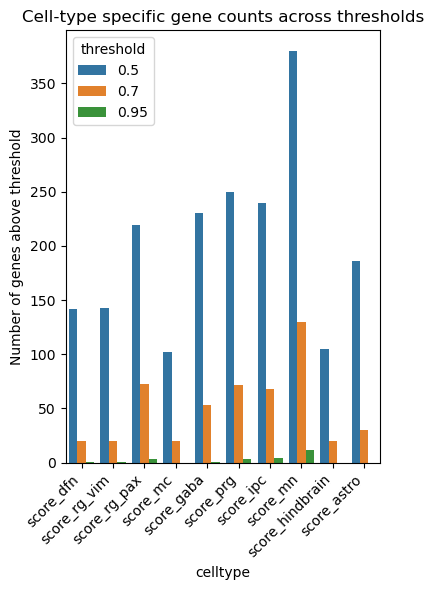

In [25]:
thresholds = [0.5, 0.7, 0.95]

data = []

for t in thresholds:
    counts = (combined_minus_3q29_15q13 > t).sum(axis=0)  # per cell type
    for celltype, value in counts.items():
        data.append({
            "celltype": celltype,
            "threshold": str(t),
            "count": value
        })

df = pd.DataFrame(data)


plt.figure(figsize=(4,6))

sns.barplot(
    data=df,
    x="celltype",
    y="count",
    hue="threshold"
)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of genes above threshold")
plt.title("Cell-type specific gene counts across thresholds")
plt.tight_layout()

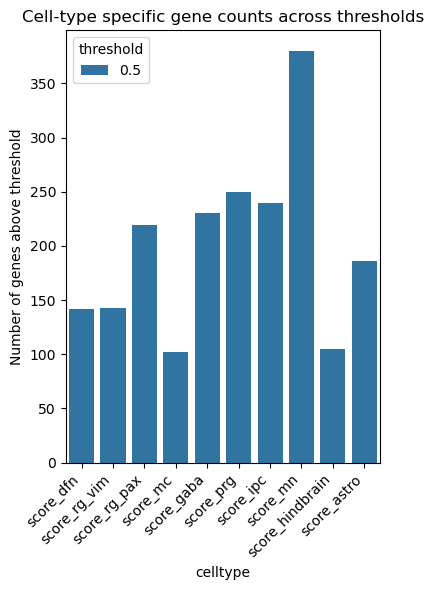

In [26]:
thresholds = [0.5]

data = []

for t in thresholds:
    counts = (combined_minus_3q29_15q13 > t).sum(axis=0)  # per cell type
    for celltype, value in counts.items():
        data.append({
            "celltype": celltype,
            "threshold": str(t),
            "count": value
        })

df = pd.DataFrame(data)


plt.figure(figsize=(4,6))

sns.barplot(
    data=df,
    x="celltype",
    y="count",
    hue="threshold"
)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of genes above threshold")
plt.title("Cell-type specific gene counts across thresholds")
plt.tight_layout()

<Axes: xlabel='gene'>

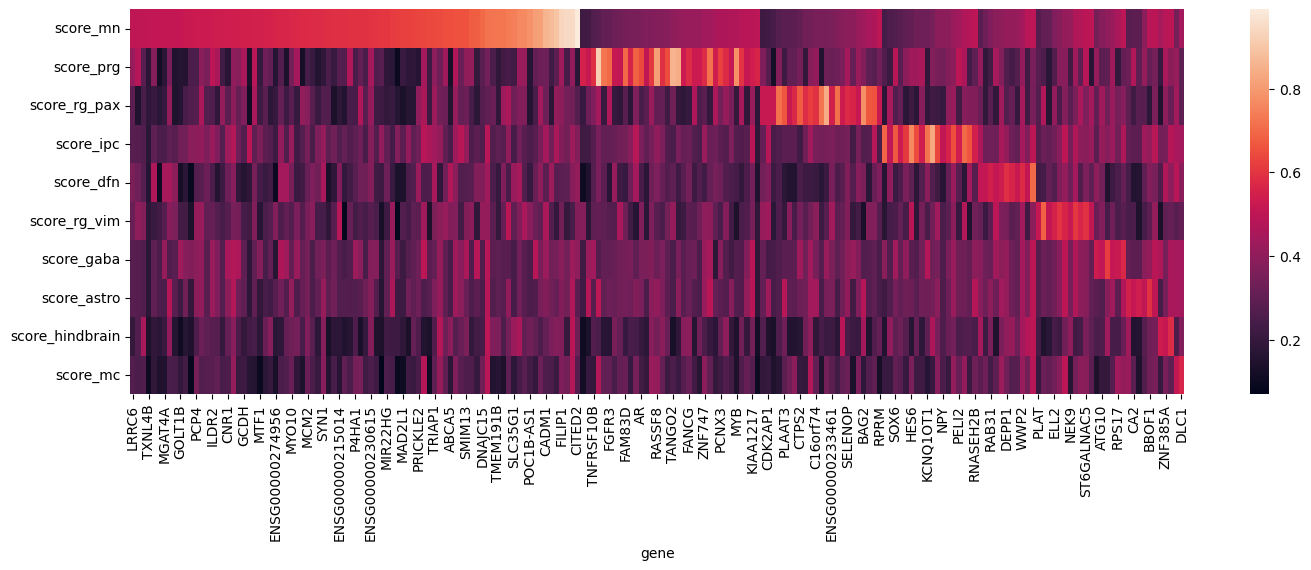

In [27]:
specific = combined_minus_3q29_15q13[(combined_minus_3q29_15q13 > 0.5).sum(axis=1) == 1]

winner = (specific > 0.5).idxmax(axis=1)

# Count how many genes belong to each cell type
block_sizes = winner.value_counts()

# Order cell types from largest block to smallest
col_order = block_sizes.index.tolist()

# Reorder columns
specific = specific[col_order]

# Make winner a categorical with the desired ordering
winner = pd.Categorical(
    winner,
    categories=col_order,
    ordered=True
)

# Sort rows by block, then by score within each block
specific = (
    specific.assign(winner=winner)
            .sort_values(["winner"] + col_order, ascending=False)
            .drop(columns="winner")
)

specific = specific.iloc[::-1]

plt.figure(figsize=(17,5))
sns.heatmap(specific.T, yticklabels=True)